# Flexible CNN模型 - Optuna
## 使用Optuna进行自动调参
参数：1889070

1. 采用**分层采样**：“每个手指固定 6 张训练、2 张测试”
能确保模型在训练时见过每一个手指，在测试时也能评估每一个手指。
2. 训练集：测试集 = 6:2，保持了合理的训练数据量，同时保证了测试的代表性。
3. **使用LR=0.001并进行学习率衰退**

#### 训练结果1
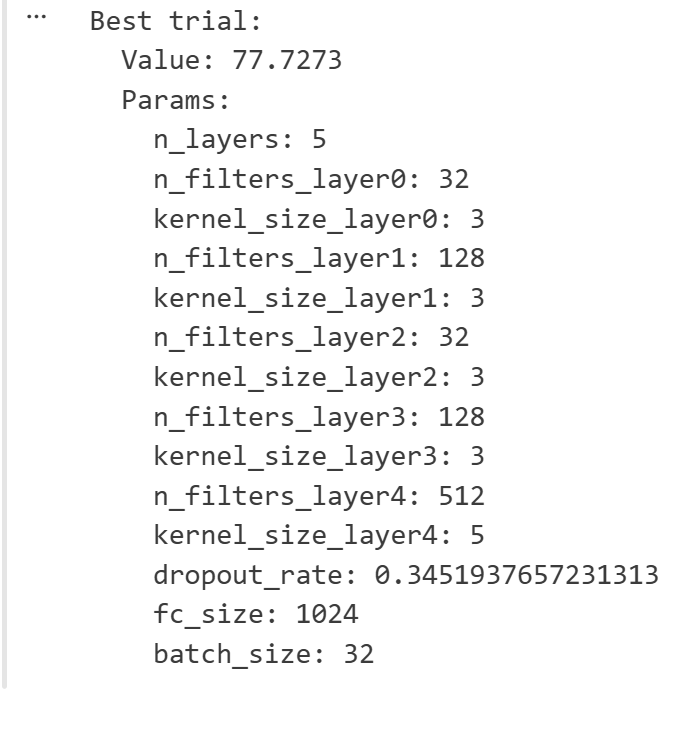
#### 训练结果2 

Best trial:
  Value: 80.9091
  Params: 
    n_layers: 6
    n_filters_layer0: 32
    kernel_size_layer0: 3
    n_filters_layer1: 32
    kernel_size_layer1: 3
    n_filters_layer2: 32
    kernel_size_layer2: 3
    n_filters_layer3: 128
    kernel_size_layer3: 3
    n_filters_layer4: 512
    kernel_size_layer4: 5
    n_filters_layer5: 32
    kernel_size_layer5: 5
    dropout_rate: 0.3495822457727959
    fc_size: 1024
    batch_size: 16

**Result: %的测试准确率**

In [41]:
import os
import optuna
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

from torch.utils.data import Subset
from collections import defaultdict
import random

In [42]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [43]:
device

device(type='cuda')

## 1. 读取指纹数据

In [44]:
class FVC2002Dataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        # 过滤出所有的 .tif 文件
        self.image_files = [f for f in os.listdir(root_dir) if f.endswith('.tif')]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.root_dir, img_name)
        
        # 加载图像并转为灰度图（指纹图通常是单通道）
        image = Image.open(img_path).convert('L')
        
        # 解析标签：例如 "10_3.tif" -> 标签为 10
        # 注意：类别索引通常从 0 开始，所以我们将 ID 减 1
        label = int(img_name.split('_')[0]) - 1
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

In [ ]:
# 临时加载数据集（仅 ToTensor）
dataset = FVC2002Dataset(root_dir='../FVC2002/Db1',
                        transform=transforms.Compose([
                        transforms.Grayscale(),
                        transforms.ToTensor()
                               ]))
loader = DataLoader(dataset, batch_size=100, shuffle=False)

def calculate_mean_std(dataset):
    """
    Calculates the mean and standard deviation of a PyTorch dataset.

    Args:
        dataset (torch.utils.data.Dataset): The dataset for which to
                                            calculate the stats. It should
                                            return image tensors.

    Returns:
        (torch.Tensor, torch.Tensor): A tuple containing the mean and
                                      standard deviation tensors, each of
                                      shape (C,).
    """
    # Create a DataLoader to iterate through the dataset in batches for efficiency.
    # shuffle=False because the order of images doesn't matter for this calculation.
    loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=0)

    # Initialize tensors to store the sum of pixel values for each (RGB) channel.
    channel_sum = torch.zeros(1)
    # Initialize tensors to store the sum of squared pixel values for each channel.
    channel_sum_sq = torch.zeros(1)
    # Initialize a counter for the total number of pixels.
    num_pixels = 0

    # Wrap the loader with tqdm to create a progress bar for monitoring.
    for images, _ in tqdm(loader, desc="Calculating Dataset Stats"):
        # Add the total number of pixels in this batch to the running total.
        num_pixels += images.size(0) * images.size(2) * images.size(3)
        
        # Sum the pixel values across the batch, height, and width dimensions,
        # leaving only the channel dimension. Add this to the running total.
        channel_sum += images.sum(dim=[0, 2, 3])
        
        # Square each pixel value, then sum them up similarly to the step above.
        channel_sum_sq += (images ** 2).sum(dim=[0, 2, 3])

    # Calculate the mean for each channel.
    mean = channel_sum / num_pixels
    # Calculate the standard deviation using the formula: sqrt(E[X^2] - E[X]^2)
    std = (channel_sum_sq / num_pixels - mean ** 2) ** 0.5

    # Return the calculated mean and standard deviation.
    return mean, std

mean, std = calculate_mean_std(dataset)
print(f"Mean: {mean}, Std: {std}")

Mean: tensor([0.8499]), Std: tensor([0.2375])


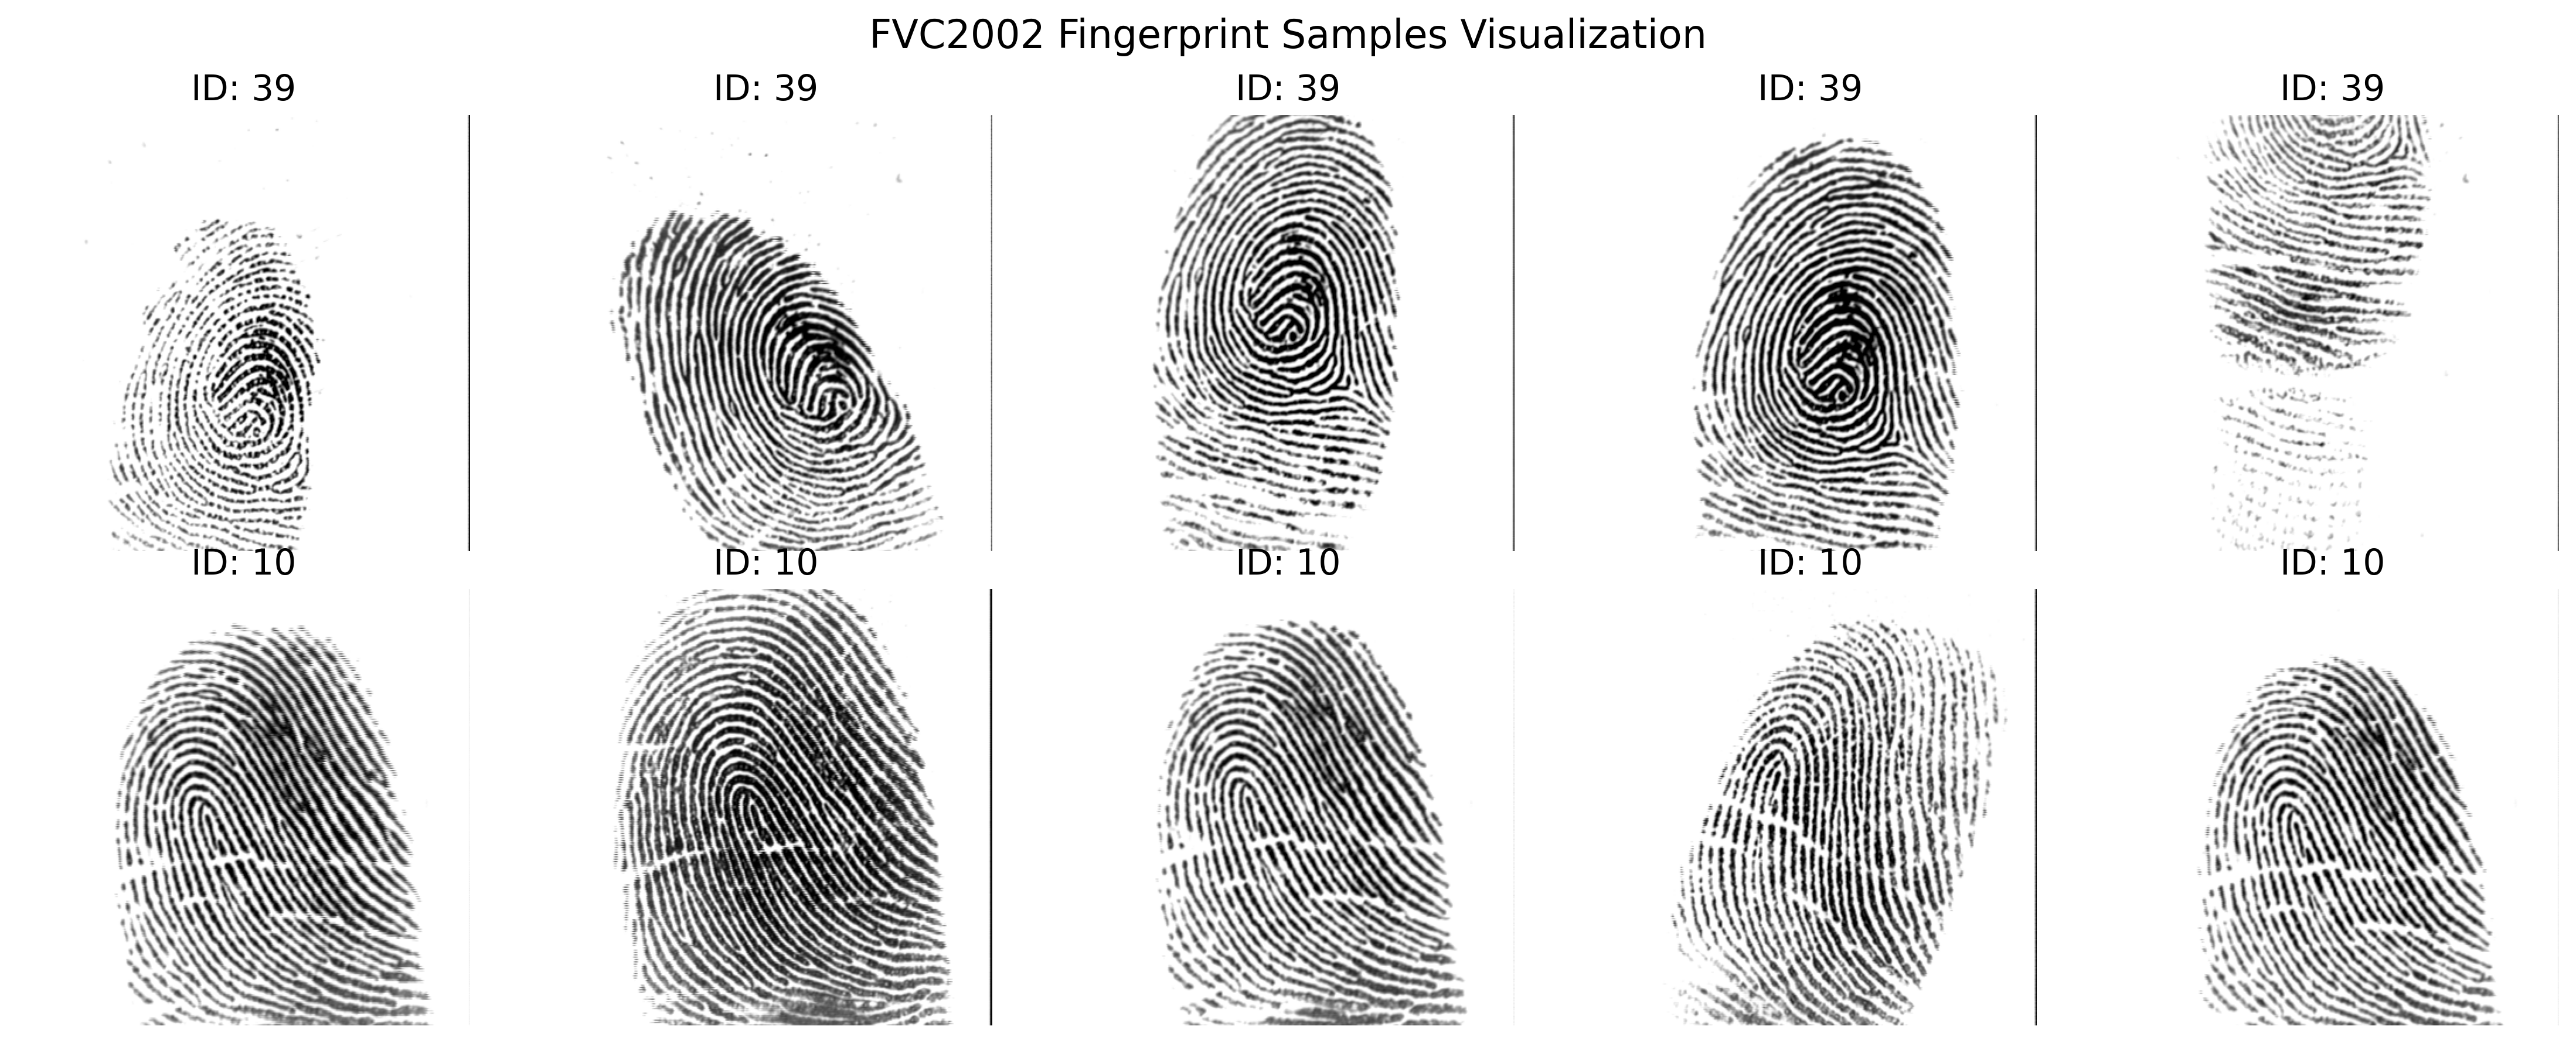

In [46]:
# 指纹图片查看
def visualize_fvc_samples(dataset, num_people=2, samples_per_person=5):
    # 1. 建立 ID 到 索引列表的映射
    # label 是 img_name.split('_')[0] - 1
    id_to_indices = {}
    for idx, img_name in enumerate(dataset.image_files):
        label = int(img_name.split('_')[0]) - 1
        if label not in id_to_indices:
            id_to_indices[label] = []
        id_to_indices[label].append(idx)

    # 2. 随机抽取指定数量的人
    selected_ids = random.sample(list(id_to_indices.keys()), num_people)

    # 3. 开始绘图
    fig, axes = plt.subplots(num_people, samples_per_person, figsize=(15, 6), dpi=300)
    fig.suptitle('FVC2002 Fingerprint Samples Visualization', fontsize=16)

    for i, person_id in enumerate(selected_ids):
        # 随机抽取该人的 5 个指纹索引
        indices = random.sample(id_to_indices[person_id], samples_per_person)
        
        for j, idx in enumerate(indices):
            image, label = dataset[idx]
            
            # 如果 image 是 Tensor (经过了 transform)，需要转回 numpy
            if torch.is_tensor(image):
                image = image.squeeze().numpy() # 移除通道维度 [1, H, W] -> [H, W]
            
            ax = axes[i, j] if num_people > 1 else axes[j]
            ax.imshow(image, cmap='gray')
            ax.set_title(f"ID: {person_id + 1}")
            ax.axis('off')

    plt.tight_layout()
    plt.show()

# 使用方法：
visualize_fvc_samples(dataset, num_people=2, samples_per_person=5)

In [47]:
class ApplyTransform(Dataset):
    """
    一个简单的装饰器类，用于给 Subset 应用特定的 transform
    """
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
        
    def __len__(self):
        return len(self.subset)

# 1. 定义两个不同的 Pipeline
# 基础操作（训练和测试共有）
base_ops = [
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.85], std=[0.2375])
]

# 训练集特有：加入随机旋转
train_transforms = transforms.Compose([
    transforms.RandomRotation(15),
    *base_ops
])

# 测试集：仅基础操作
test_transforms = transforms.Compose(base_ops)

# 2. 原始数据集加载时不带 transform (或者只带 Resize)
full_dataset = FVC2002Dataset(root_dir='../FVC2002/Db1', transform=None)

# --- 2. 建立标签到索引的映射 (字典结构) ---
# 这一步是为了找出每个手指对应的 8 张图分别在列表的哪个位置
label_to_indices = defaultdict(list)
for idx, img_name in enumerate(full_dataset.image_files):
    # 使用与你 Dataset 类中一致的解析逻辑
    label = int(img_name.split('_')[0]) - 1
    label_to_indices[label].append(idx)

train_indices = []
test_indices = []

# --- 3. 核心：对每一个类别固定分配 6/2 ---
# 确保每个类（手指）都参与了划分
for label, indices in label_to_indices.items():
    # 随机打乱当前手指的 8 张图索引
    random.shuffle(indices)
    
    # 取前 6 张作为训练，后 2 张作为测试
    train_indices.extend(indices[:6])
    test_indices.extend(indices[6:])

# --- 4. 创建 Subset 并应用不同的 Transform ---
# 先利用索引创建子集
train_subset = Subset(full_dataset, train_indices)
test_subset = Subset(full_dataset, test_indices)
# 5. 分别包装，应用不同的 transform
train_dataset = ApplyTransform(train_subset, transform=train_transforms)
test_dataset = ApplyTransform(test_subset, transform=test_transforms)

In [48]:
len(train_dataset), len(test_dataset)

(660, 220)

In [49]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

## 2. 构建模型

In [50]:
# 设计一个灵活的 CNN 模型，允许用户指定卷积层数、每层的滤波器数量、卷积核大小、Dropout率、全连接层大小等超参数
# 在训练之前需要进行一次dummy forward，来根据卷积层的输出特征图大小自动计算全连接层的输入维度

class FlexibleCNN(nn.Module):
    def __init__(self, input_shape, n_layers, n_filters, kernel_sizes, dropout_rate, fc_size, num_classes):
        super(FlexibleCNN, self).__init__()
        blocks = []
        in_channels = input_shape[0] # grey fingerprint

        for i in range(n_layers):
            out_channels = n_filters[i]
            kernel_size = kernel_sizes[i]
            padding = kernel_size // 2 # 保持尺寸不变
            
            block = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=1, padding=padding),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2, stride=2)
            )
            blocks.append(block)
            in_channels = out_channels

        self.features = nn.Sequential(*blocks)

        # --- 加入全局平均池化层 ---
        # 无论特征图多大，都压缩成 (batch, channels, 1, 1)
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        # 2. 执行 Dummy Forward 以计算全连接层的输入尺寸
        self.flattened_size = self._get_conv_output_shape(input_shape)

        # 3. 构建分类器 (在 __init__ 中完成，确保参数被注册)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(self.flattened_size, fc_size),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(fc_size, num_classes)
        )


    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)  # 应用全局平均池化
        x = torch.flatten(x, 1) # 展平为 (batch_size, flattened_size)
        x = self.classifier(x)
        return x
    
    def _get_conv_output_shape(self, shape):
        with torch.no_grad():
            batch_size = 1
            dummy_input = torch.ones(batch_size, *shape)
            output_tensor = self.features(dummy_input)
            output_tensor = self.gap(output_tensor)  # 应用全局平均池化
            output_size = output_tensor.view(batch_size, -1).size(1)
            return output_size

def get_flexible_cnn(num_classes=110):
    input_shape = (1, 224, 224) # 单通道输入，224x224
    n_layers = 5
    n_filters = [32, 64, 128, 256, 512]
    kernel_sizes = [3, 3, 3, 3, 3]
    dropout_rate = 0.4
    fc_size = 512
    
    model = FlexibleCNN(input_shape, n_layers, n_filters, kernel_sizes, dropout_rate, fc_size, num_classes)
    return model

## 3. 模型训练

In [51]:
# 1. 训练一个 Epoch 的函数
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    train_loss = running_loss / len(loader)
    train_acc = 100. * correct / total
    return train_loss, train_acc

In [52]:
# 2. 验证/测试函数 (基于你提供的 evaluate 修改)
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
    val_loss = running_loss / len(loader)
    val_acc = 100. * correct / total
    return val_loss, val_acc

In [53]:
# 3. 总训练控制函数
def train(model, train_loader, test_loader, criterion, optimizer, device, scheduler=None, epochs=20):
    # 用于记录历史数据以便绘图
    history = {
        'train_loss': [], 'train_acc': [],
        'test_loss': [], 'test_acc': []
    }
    
    print(f"开始训练，设备: {device}")
    for epoch in range(epochs):
        # 训练阶段
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        # 验证阶段
        test_loss, test_acc = validate(model, test_loader, criterion, device)
        
        # 每个 epoch 结束更新学习率
        if scheduler is not None:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(test_acc)  # 以验证准确率为指标调整学习率
            else:
                scheduler.step()  # 其他类型的调度器直接调用 step()
            current_lr = optimizer.param_groups[0]['lr']

        # 记录历史
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        
        print(f"[Epoch {epoch+1}/{epochs}](LR: {current_lr:.6f}) -> "
              f"Train Acc: {train_acc:.2f}%, Test Acc: {test_acc:.2f}% | "
              f"Train Loss: {train_loss:.4f}")

    # 训练结束后进行可视化
    plot_history(history)
    return history

# 4. 可视化函数
def plot_history(history):
    epochs = range(1, len(history['train_acc']) + 1)
    
    plt.figure(figsize=(12, 5))
    
    # 绘制准确率曲线
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_acc'], 'b-', label='Training Acc')
    plt.plot(epochs, history['test_acc'], 'r-', label='Test Acc')
    plt.title('Training and Test Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    
    # 绘制损失曲线
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_loss'], 'b-', label='Training Loss')
    plt.plot(epochs, history['test_loss'], 'r-', label='Test Loss')
    plt.title('Training and Test Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

### Optuna自动调参

In [54]:
# 定义搜索空间
def design_search_space(trial):
    n_layers = trial.suggest_int('n_layers', 4, 7)
    n_filters = []
    kernel_sizes = []
    for i in range(n_layers):
        n_filters.append(trial.suggest_categorical(f'n_filters_layer{i}', [16, 32, 64, 128, 256, 512]))
        kernel_sizes.append(trial.suggest_categorical(f'kernel_size_layer{i}', [3, 5]))
    dropout_rate = trial.suggest_float('dropout_rate', 0.2, 0.5)
    fc_size = trial.suggest_categorical('fc_size', [256, 512, 1024])
    
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])

    return {
    "n_layers": n_layers,
    "n_filters": n_filters,
    "kernel_sizes": kernel_sizes,
    "dropout_rate": dropout_rate,
    "fc_size": fc_size,
    "batch_size": batch_size,
}

In [55]:
# 定义 Optuna 的目标函数
def objective(trial, n_epochs=100):
    # 1. 设计搜索空间
    params = design_search_space(trial)
    
    # 2. 创建模型
    model = FlexibleCNN(input_shape=(1, 224, 224), 
                        n_layers=params['n_layers'], 
                        n_filters=params['n_filters'], 
                        kernel_sizes=params['kernel_sizes'], 
                        dropout_rate=params['dropout_rate'], 
                        fc_size=params['fc_size'], 
                        num_classes=110).to(device)
    
    # 3. 定义损失函数和优化器
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min=1e-5)

    # 4. 创建 DataLoader（使用 Optuna 建议的 batch size）
    train_loader = DataLoader(train_dataset, batch_size=params['batch_size'], shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=params['batch_size'], shuffle=False)
    
    # 5. 训练模型, 余弦退火学习率调整
    for epoch in range(n_epochs):
        _, _ = train_epoch(model, train_loader, criterion, optimizer, device)
        scheduler.step()  # 每个 epoch 结束后更新学习率
    
    # 6. 返回验证集的最终准确率作为优化目标
    _, final_test_acc = validate(model, test_loader, criterion, device)

    # 7. 存储模型参数数量到 Optuna 的 trial 中，方便后续分析
    trial.set_user_attr("num_parameters", sum(p.numel() for p in model.parameters()))

    return final_test_acc

In [56]:
# 进行 Optuna 调参, 先搜索20次，找到一个不错的配置后再增加搜索次数
# 一次3分钟左右，20次大概是60分钟
study = optuna.create_study(direction='maximize')
n_trials = 20
# 进度条
pbar = tqdm(total=n_trials)

def tqdm_callback(study, trial):
    pbar.update(1)

study.optimize(objective, n_trials=n_trials, callbacks=[tqdm_callback])
pbar.close()

[I 2026-03-05 16:02:09,359] A new study created in memory with name: no-name-ca5e3d06-601f-4a40-b617-d23a17ab9fcd
100%|██████████| 20/20 [52:50<00:00, 158.55s/it]


In [57]:
# 时间允许的话，可以增加搜索次数，例如 n_trials=50 或 100，以找到更优的配置
# 增加搜索次数（在原有基础上再跑 30 次）
# study.optimize(lambda trial: objective(trial, n_epochs=100), n_trials=30)

/tmp/ipykernel_8983/2952741664.py:2: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


<Axes: title={'center': 'Optimization History Plot'}, xlabel='Trial', ylabel='Objective Value'>

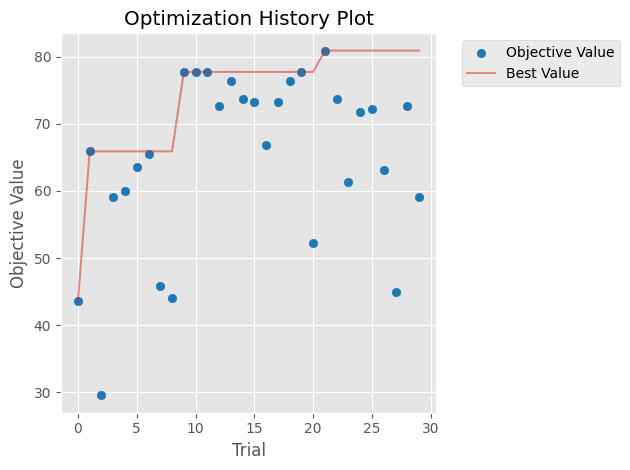

In [66]:
# 可视化优化结果
optuna.visualization.matplotlib.plot_optimization_history(study)

In [63]:
# optuna.visualization.matplotlib.plot_param_importances(study)

In [68]:
# 查看前五个 trial 的参数和结果
df_trials = study.trials_dataframe()
df_trials.sort_values(by='value', ascending=False, inplace=True)
df_trials.head()

ImportError: Tried to import 'pandas' but failed. Please make sure that the package is installed correctly to use this feature. Actual error: No module named 'pandas'.

In [69]:
# 获取最佳 trial 的参数
best_trial = study.best_trial
print("Best trial:")
print(f"  Value: {best_trial.value:.4f}")
print("  Params: ")
for key, value in best_trial.params.items():
    print(f"    {key}: {value}")

Best trial:
  Value: 80.9091
  Params: 
    n_layers: 6
    n_filters_layer0: 32
    kernel_size_layer0: 3
    n_filters_layer1: 32
    kernel_size_layer1: 3
    n_filters_layer2: 32
    kernel_size_layer2: 3
    n_filters_layer3: 128
    kernel_size_layer3: 3
    n_filters_layer4: 512
    kernel_size_layer4: 5
    n_filters_layer5: 32
    kernel_size_layer5: 5
    dropout_rate: 0.3495822457727959
    fc_size: 1024
    batch_size: 16


In [65]:
# 时间允许的话，可以增加搜索次数，例如 n_trials=50 或 100，以找到更优的配置
# 增加搜索次数（在原有基础上再跑 10 次）
# study.optimize(lambda trial: objective(trial, n_epochs=100), n_trials=30)
n_trials = 10
# 进度条
pbar = tqdm(total=n_trials)

def tqdm_callback(study, trial):
    pbar.update(1)

study.optimize(objective, n_trials=n_trials, callbacks=[tqdm_callback])
pbar.close()

100%|██████████| 10/10 [20:35<00:00, 123.58s/it]


In [ ]:
# 保存study以方便下次继续
import joblib

# 运行完之后保存
joblib.dump(study, "study_snapshot.pkl")

# # 下次训练前载入
# study = joblib.load("study_snapshot.pkl")

# # 继续优化
# study.optimize(objective, n_trials=20)

['study_snapshot.pkl']